# Choice of couplings in flow matching

This notebook demonstrates flow matching with three different choices of couplings between the source $\mu_0$ and target $\mu_1$.

* **Independent coupling (I-FM)**: $(x_0, x_1)$ is sampled from the independent coupling, i.e. $\pi = \mu_0 \otimes \mu_1$, see e.g. {cite}`albergo:23,lipman:22`
* **Minibatch OT coupling (OT-FM)**: $(x_0, x_1)$ are paired using mini-batch OT, see e.g. {cite}`pooladian:23,tong:23`.
* **Semi-discrete OT coupling (SD-FM)**: $(x_0, x_1)$ are paired using semidiscrete OT, introduced in {cite}`mousavi:25`.

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Use GPU 0 only

In [2]:
import pickle
from collections.abc import Iterable
from typing import Callable, Dict, Literal, Optional, Tuple

# For loading images
from PIL import Image, ImageOps
from tqdm import tqdm

import jax
import jax.numpy as jnp
import jax.random as jr
import jax.tree_util as jtu

# Basic imports
import numpy as np

import optax
from diffrax import Dopri5, ODETerm, SaveAt, diffeqsolve
from flax import nnx

import matplotlib.animation as mpa
import matplotlib.pyplot as plt
from IPython import display
from matplotlib.animation import FuncAnimation, PillowWriter

from ott.geometry import costs, pointcloud
from ott.geometry import semidiscrete_pointcloud as sdpc
from ott.neural.data import ot_dataloader
from ott.neural.methods import flow_matching as fm
from ott.neural.networks.velocity_field import mlp
from ott.problems.linear import semidiscrete_linear_problem as sdlp
from ott.solvers import linear
from ott.solvers.linear import semidiscrete

# OTT tools
from ott.tools import plot, unreg

#
TRAIN = False  # Set to True to train models, otherwise load existing weights
import os
import pathlib

WEIGHTS_DIR = pathlib.Path(os.getcwd()).joinpath("weights")

## Load image and convert to point cloud

In [3]:
# download penrose triangle image
!wget -nc "https://upload.wikimedia.org/wikipedia/commons/6/6e/Pentriangle.png"

File ‘Pentriangle.png’ already there; not retrieving.



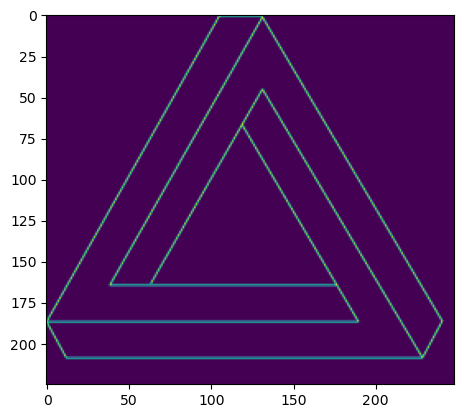

In [4]:
img = ImageOps.grayscale(Image.open("Pentriangle.png"))
img = ImageOps.invert(img)
img = np.array(img)
plt.imshow(img)

# Extract image as point cloud
w, h = img.shape
x_grid, y_grid = np.meshgrid(range(w), range(h), indexing="ij")
xy_grid = np.vstack([x_grid.reshape(-1) / h, y_grid.reshape(-1) / w]).T
probs = img.reshape(-1)
probs = probs / probs.sum()
xy_grid = xy_grid[probs > 0]
probs = probs[probs > 0]

## Define simple flow model and training loop

In [5]:
key = jr.key(42)
p = jax.device_put(probs)
x_target = jax.device_put(xy_grid)
# normalize training data
x_target = x_target - x_target.mean(axis=0)
x_target = x_target / x_target.std(axis=0)

## Train semidiscrete potential

In [6]:
geom = sdpc.SemidiscretePointCloud(
    sampler=jr.normal, y=x_target, epsilon=0.0, cost_fn=costs.SqEuclidean()
)
error_eval_every = 5000


def print_callback(state: semidiscrete.SemidiscreteState) -> None:
    it = state.it.item()
    if it > 0 and it % error_eval_every == 0:
        loss = state.errors[it // error_eval_every - 1].item()
        print(f"It. {it:5d}, marginal χ2 error={loss:.4f}")


prob = sdlp.SemidiscreteLinearProblem(geom)
solver = semidiscrete.SemidiscreteSolver(
    num_iterations=25_000,
    batch_size=128,
    optimizer=optax.adagrad(learning_rate=0.001),
    error_eval_every=error_eval_every,
    callback=print_callback,
)
sd_sol = jax.jit(solver)(key, prob)

It.  5000, marginal χ2 error=0.3213
It. 10000, marginal χ2 error=0.2215
It. 15000, marginal χ2 error=0.3462
It. 20000, marginal χ2 error=0.1218
It. 25000, marginal χ2 error=0.1218


## Visualize semidiscrete potential

The optimal semidiscrete potential $g$ is defined on the support of $\mu_1$, i.e. `x_target`

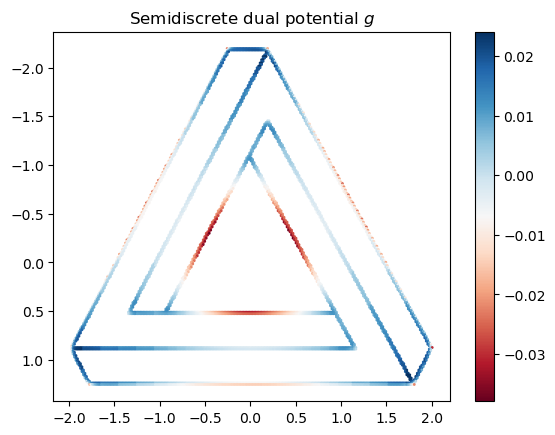

In [7]:
plt.scatter(x_target[:, 1], x_target[:, 0], c=sd_sol.g, cmap="RdBu", s=1)
plt.colorbar()
plt.title("Semidiscrete dual potential $g$")
plt.gca().invert_yaxis()

## Train flow matching models

Here we train three FM models with different choices of coupling.

In [8]:
def ifm_loader(
    key: jax.Array, x: jax.Array, batch_size: int
) -> Iterable[tuple[jax.Array, jax.Array]]:
    while True:
        key, subkey1, subkey2 = jr.split(key, 3)
        x0 = jr.normal(subkey1, shape=(batch_size, x.shape[1]))
        x1 = x[jr.permutation(subkey2, x.shape[0])[:batch_size]]
        yield x0, x1


batch_size = 128
lr = 3e-4

methods = ["semidiscrete", "minibatch_ot", "ifm"]
models = {}
optimizers = {}
for what in methods:
    model = mlp.MLP(dim=2, rngs=nnx.Rngs(1), hidden_dims=[128, 128, 128, 128])
    optimizer = nnx.Optimizer(model, optax.adam(lr))
    models[what] = model
    optimizers[what] = optimizer

dl_ifm_iter = ifm_loader(jr.key(0), x_target, batch_size)
dl_ot = ot_dataloader.LinearOTDataloader(
    jr.key(0), dl_ifm_iter, epsilon=0.1, relative_epsilon="std"
)
dl_ot_iter = iter(dl_ot)
dl_sd = sd_sol.to_dataloader(jr.key(0), batch_size=batch_size)
dl_sd_iter = iter(dl_sd)
dl_iters = {
    "semidiscrete": dl_sd_iter,
    "minibatch_ot": dl_ot_iter,
    "ifm": dl_ifm_iter,
}

In [9]:
def train(
    key: jax.Array,
    model: nnx.Module,
    optimizer: nnx.Optimizer,
    dl_iter: Iterable[tuple[jax.Array, jax.Array]],
    num_iters: int = 100_000,
    print_iter: int = 10_000,
) -> nnx.Module:
    fm_step = nnx.jit(fm.flow_matching_step)
    step_rngs = nnx.Rngs(0)
    for it in tqdm(range(num_iters)):
        key, subkey = jr.split(key, 2)
        x0, x1 = next(dl_iter)
        batch = fm.interpolate_samples(subkey, x0, x1)
        metrics = fm_step(model, optimizer, batch, rngs=step_rngs)
        if it % print_iter == 0:
            print(f"iteration {it} - {metrics}")
    return model


if TRAIN:
    for what in methods:
        model = models[what]
        optimizer = optimizers[what]
        dl_iter = dl_iters[what]
        print(f"Training model={what}")
        models[what] = train(jr.key(0), model, optimizer, dl_iter)
        print(f"Saving weights for model={what}")
        _, state = nnx.split(model)
        with open(WEIGHTS_DIR.joinpath(f"params_{what}.pkl"), "wb") as f:
            pickle.dump(state, f)
else:
    for what in methods:
        print(f"Loading weights for model={what}")
        model = models[what]
        graphdef, _ = nnx.split(model)
        with open(WEIGHTS_DIR.joinpath(f"params_{what}.pkl"), "rb") as f:
            state = pickle.load(f)
        models[what] = nnx.merge(graphdef, state)

Loading weights for model=semidiscrete
Loading weights for model=minibatch_ot
Loading weights for model=ifm


## Sample trajectories from trained model

In [10]:
# sample from trained model


def f(t: jax.Array, x: jax.Array, args: nnx.Module) -> jax.Array:
    model = args
    t = jnp.repeat(t, x.shape[0], axis=0)
    v_t = model(t, x)
    return v_t


term = ODETerm(f)
solver = Dopri5()
N = 10_000
y0 = jr.normal(key, shape=(N, 2))
sols = {}
for what in methods:
    sols[what] = diffeqsolve(
        term,
        solver,
        t0=0.0,
        t1=1.0,
        dt0=0.01,
        y0=y0,
        args=models[what],
        saveat=SaveAt(ts=jnp.linspace(0, 1, 190), t1=False),
    )

In [11]:
titles = {
    "semidiscrete": "SD-FM",
    "minibatch_ot": f"OT-FM, $B$ = 128",
    "ifm": "I-FM",
}

In [12]:
def to_video(ani: mpa.FuncAnimation) -> None:
    display.display(display.HTML(ani.to_html5_video()))


fig, axs = plt.subplots(1, len(methods), figsize=(10, 3))
i = -1
scs = [
    ax.scatter(
        sols[what].ys[i, :, 1],
        sols[what].ys[i, :, 0],
        alpha=0.3,
        color="k",
        s=1,
    )
    for (ax, what) in zip(axs, methods)
]
for ax, what in zip(axs, methods):
    ax.axis("off")
    ax.margins(0)
    ax.figure.tight_layout(pad=0)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.invert_yaxis()
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(titles[what])


def update(i):
    for j, m in enumerate(methods):
        pts = sols[m].ys[i, :, ::-1]
        scs[j].set_offsets(pts)
    return None


for i in range(len(sols[methods[0]].ts)):
    update(i)
ani = FuncAnimation(fig, update, frames=len(sols[methods[0]].ts), interval=50)
plt.close()

In [13]:
to_video(ani)